In [7]:
from collections import namedtuple
from typing import Tuple

import os
import subprocess
import pickle
import numpy as np
import matplotlib.pyplot as plt

#### Utilities

In [8]:
TestResult = namedtuple(
    "TestResult", 
    ["crossings", "times"]
)

In [9]:
def test_minimal_crossing_edges(n0: int, n: int, m: int, colors: int, reps: int) -> Tuple[TestResult, TestResult] | None:
    try:
        result = subprocess.run(
            ["../build/minimal_crossing_edges", str(5), str(n0), str(m), str(n), str(colors), str(reps)],
            check=True,
            capture_output=True,
            text=True,
        )
    except subprocess.CalledProcessError as e:
        print(f"Error generating graph: {e}")
        return None
    
    output_lines = result.stdout.strip().splitlines()
    if len(output_lines) < 1:
        print("Unexpected output format")
        return None
    
    values = list(map(float, output_lines[0].split()))

    return TestResult(crossings=values[0], times=[2]), TestResult(crossings=values[1], times=[2])

#### Crossing Edges Minimalization

In [10]:
GRAPH_N0 = 5
GRAPH_N_VALUES = list(range(7, 102, 5))
GRAPH_M_VALUES = list(range(1, 6, 1))

REPETITIONS = 100
ALWAYS_REWRITE = True

In [11]:
for m in GRAPH_M_VALUES:
    for k in GRAPH_M_VALUES:
        output_filename = f"cache/crossing_edges_m{m}_k{k}.pkl"
        
        if os.path.exists(output_filename) and not ALWAYS_REWRITE:
            continue

        results = []
        for n in GRAPH_N_VALUES:
            result = test_minimal_crossing_edges(GRAPH_N0, n, m, k, REPETITIONS)
            if not result:
                print("Experiment failed")
                exit(1)
            
            results.append(result)

        with open(output_filename, "wb") as f:
            pickle.dump((GRAPH_N_VALUES, results), f)

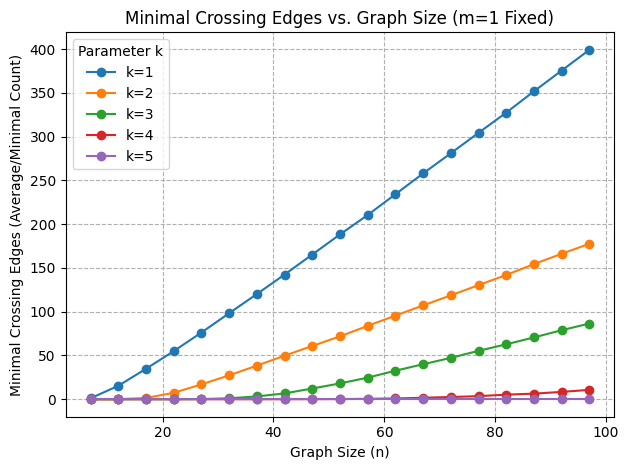

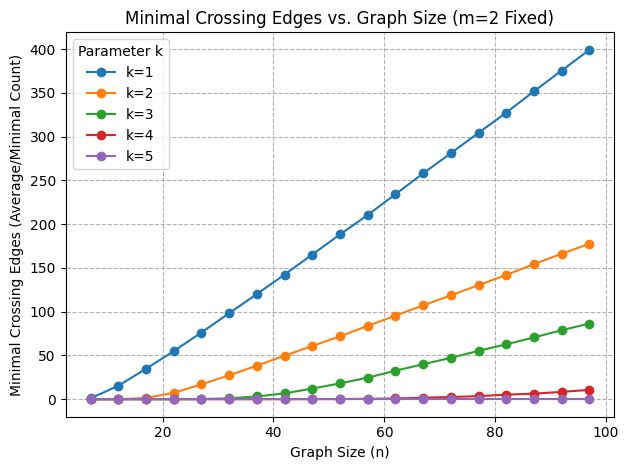

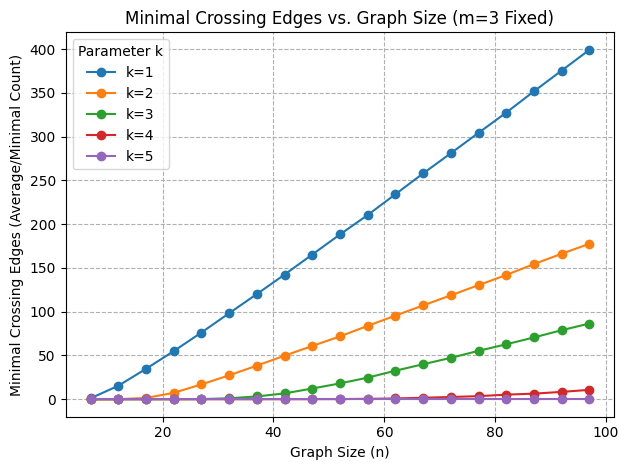

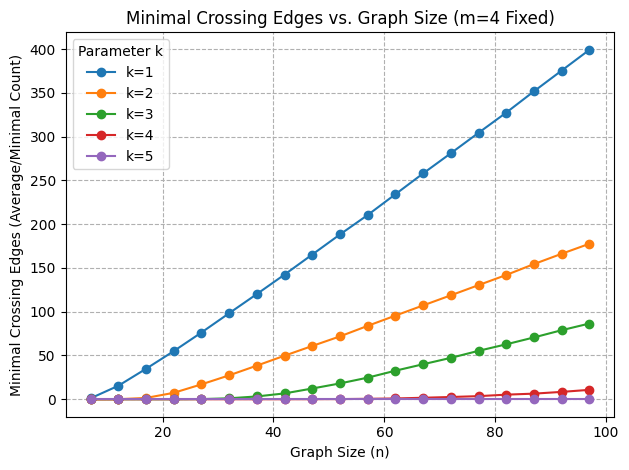

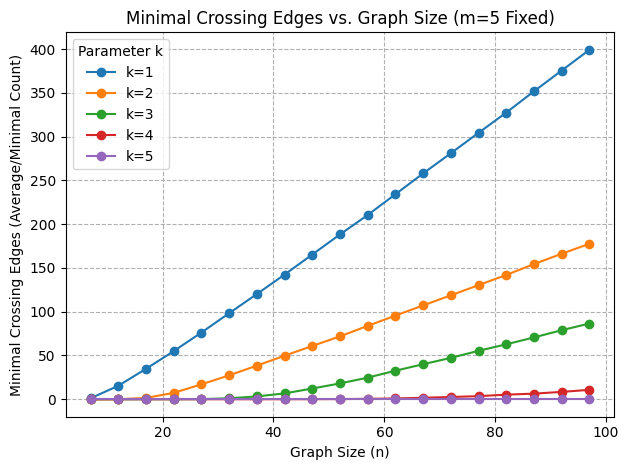

In [12]:
for fixed_m in GRAPH_M_VALUES:    
    for k in GRAPH_M_VALUES:
        with open(f"cache/crossing_edges_m{m}_k{k}.pkl", "rb") as f:
            n_values, results = pickle.load(f)
        
        crossings = [res[0] for res in results]
        crossings = [crossing.crossings for crossing in crossings]

        plt.plot(n_values, crossings, label=f'k={k}', marker='o', linestyle='-') 

    plt.title(f'Minimal Crossing Edges vs. Graph Size (m={fixed_m} Fixed)')
    plt.xlabel('Graph Size (n)')
    plt.ylabel('Minimal Crossing Edges (Average/Minimal Count)')
    plt.legend(title='Parameter k')
    plt.grid(True, linestyle='--')
    plt.tight_layout()
    plt.show()